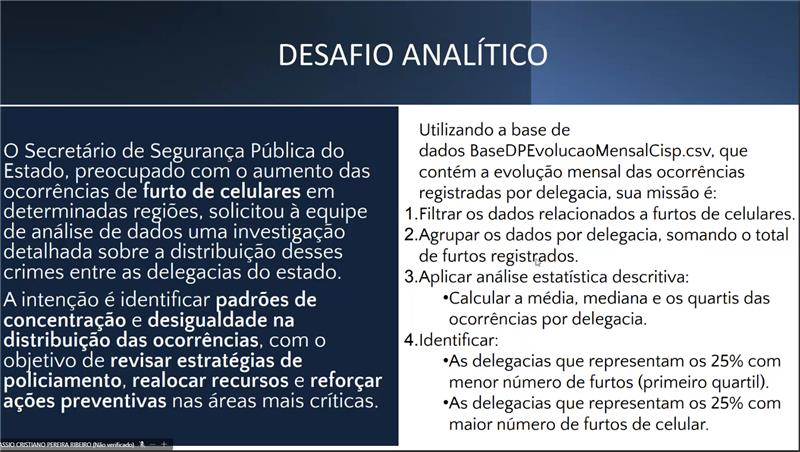

In [64]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv', sep= ';', encoding='latin1')
df

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36898,159,10,2025,2025m10,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,4.0,0.0,37,2,0,0,0,0,163,2
36899,165,10,2025,2025m10,33,5,Mangaratiba,3302601,Interior,1,...,4.0,0.0,21,0,0,0,0,0,196,2
36900,166,10,2025,2025m10,33,5,Angra dos Reis,3300100,Interior,3,...,12.0,0.0,82,8,0,1,0,0,682,2
36901,167,10,2025,2025m10,43,5,Paraty,3303807,Interior,1,...,2.0,1.0,11,1,0,0,0,0,195,2


In [65]:
df_furto_celular_dp = df.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_celular_dp =  df_furto_celular_dp.sort_values(by='furto_celular', ascending=False)
df_furto_celular_dp

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
...,...,...
87,104,72
77,92,63
131,157,55
114,138,52


In [66]:
array_furto_celular_dp = np.array(df_furto_celular_dp['furto_celular'])

In [67]:
media = np.mean(array_furto_celular_dp)
mediana = np.median(array_furto_celular_dp)
q1 = np.quantile(array_furto_celular_dp, 0.25)
q2 = np.quantile(array_furto_celular_dp, 0.50)
q3 = np.quantile(array_furto_celular_dp, 0.75)
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_inferior = q1 - 1.5 * iqr

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

print(f"A distância é {distanciaDEC}")
print(f'O IQR é {iqr}')
print(f'O limite superior é {limite_superior}')
print(f'O limite inferior é {limite_inferior}') 
# quando o limite inferior for negativo, considerar como nao tendo outlier inferior


A média é 3338.1159420289855
A mediana é 1633.5
Primeiro quartil (Q1): 449.0
Segundo quartil (Q2, Mediana): 1633.5
Terceiro quartil (Q3): 4498.25
A distância é 104.35359302289473
O IQR é 4049.25
O limite superior é 10572.125
O limite inferior é -5624.875


In [68]:
outliers_furto_celular_dp = df_furto_celular_dp.loc[(df_furto_celular_dp['furto_celular'] > limite_superior) | (df_furto_celular_dp['furto_celular'] < limite_inferior)]
outliers_furto_celular_dp

,cisp,furto_celular
12,16,24879
2,5,23117
10,14,16945
8,12,16008
0,1,14968
5,9,14159
6,10,14105
1,4,13318
14,18,12939
28,32,12206


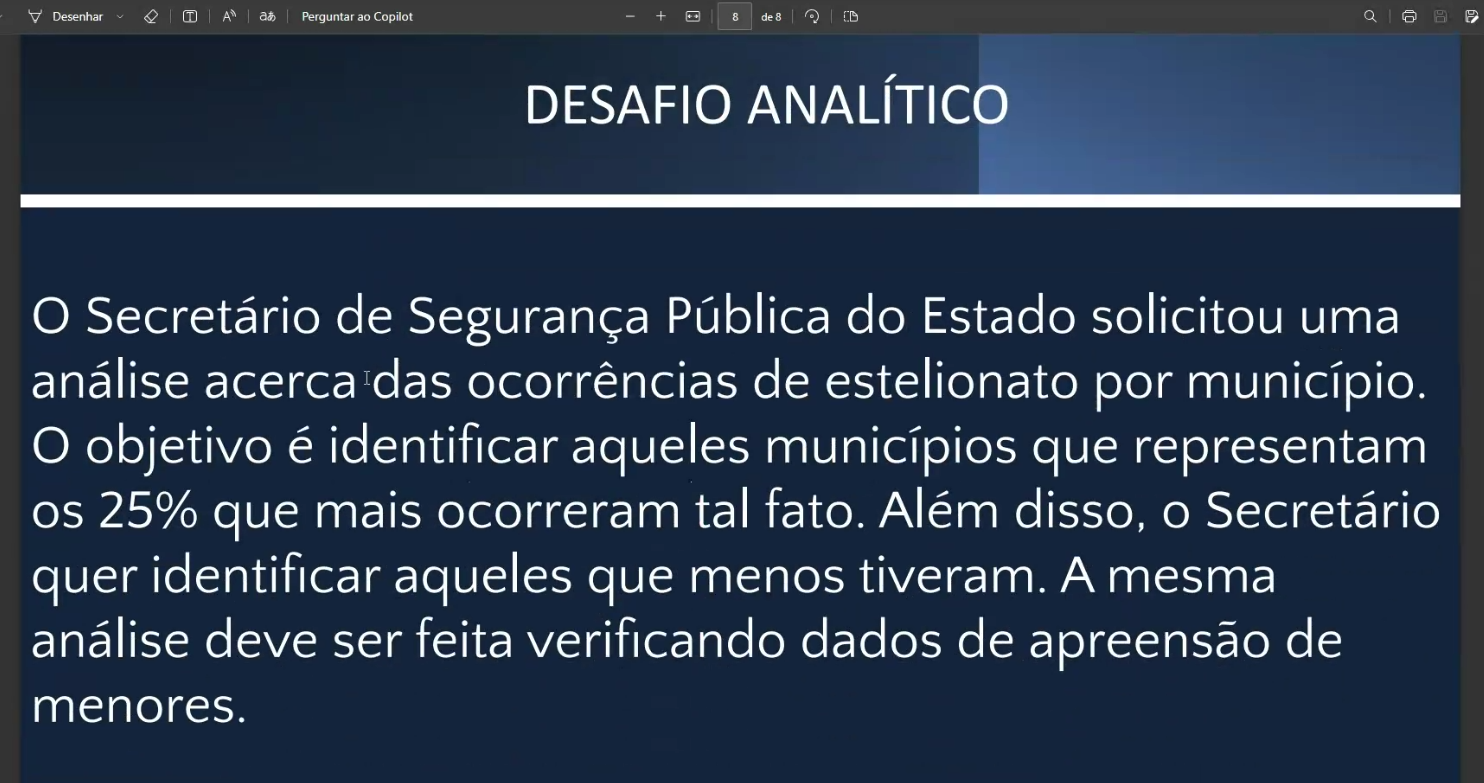

In [69]:
dfM = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseMunicipioMensal.csv', sep= ';', encoding='latin1')
dfM

,fmun_cod,fmun,ano,mes,mes_ano,regiao,hom_doloso,lesao_corp_morte,latrocinio,cvli,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,3300100,Angra dos Reis,2014,1,2014m01,Interior,11,0,0,11,...,8,0,98,13,3,0,0,0,561,3
1,3300159,Aperibé,2014,1,2014m01,Interior,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
2,3300209,Araruama,2014,1,2014m01,Interior,2,0,0,2,...,5,0,91,10,1,0,0,0,480,3
3,3300225,Areal,2014,1,2014m01,Interior,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,3300233,Armação dos Búzios,2014,1,2014m01,Interior,2,0,0,2,...,3,2,46,0,0,0,0,0,309,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13060,3306008,Três Rios,2025,10,2025m10,Interior,3,0,0,3,...,22,0,68,3,0,0,0,0,536,2
13061,3306107,Valença,2025,10,2025m10,Interior,0,0,0,0,...,8,3,31,3,1,0,0,0,227,2
13062,3306156,Varre-Sai,2025,10,2025m10,Interior,0,0,0,0,...,1,0,5,0,0,0,0,0,20,2
13063,3306206,Vassouras,2025,10,2025m10,Interior,1,0,0,1,...,1,0,15,2,0,0,0,0,139,2


In [70]:
df_estelionato_dp = dfM.groupby('fmun')['estelionato'].sum().reset_index()
df_estelionato_dp =  df_estelionato_dp.sort_values(by='estelionato', ascending=False)
df_estelionato_dp

,fmun,estelionato
67,Rio de Janeiro,459529
47,Niterói,38230
24,Duque de Caxias,29747
49,Nova Iguaçu,28700
77,São Gonçalo,28425
...,...,...
35,Laje do Muriaé,126
16,Carapebus,124
89,Varre-Sai,102
83,São Sebastião do Alto,100


In [71]:
array_df_estelionato_dp = np.array(df_estelionato_dp['estelionato'])

In [72]:
media = np.mean(array_df_estelionato_dp)
mediana = np.median(array_df_estelionato_dp)
q1 = np.quantile(array_df_estelionato_dp, 0.25)
q2 = np.quantile(array_df_estelionato_dp, 0.50)
q3 = np.quantile(array_df_estelionato_dp, 0.75)

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
print(f"A distância é {distanciaDEC}")

A média é 9197.141304347826
A mediana é 1100.0
Primeiro quartil (Q1): 398.75
Segundo quartil (Q2, Mediana): 1100.0
Terceiro quartil (Q3): 5275.5
A distância é 736.1037549407115


In [73]:
munic_acima_q3 = df_estelionato_dp.loc[df_estelionato_dp['estelionato'] > q3]
munic_acima_q3

,fmun,estelionato
67,Rio de Janeiro,459529
47,Niterói,38230
24,Duque de Caxias,29747
49,Nova Iguaçu,28700
77,São Gonçalo,28425
14,Campos dos Goytacazes,18605
81,São João de Meriti,18575
36,Macaé,14653
54,Petrópolis,13907
8,Belford Roxo,13147


In [74]:
munic_acima_q1 = df_estelionato_dp.loc[df_estelionato_dp['estelionato'] < q1]
munic_acima_q1

,fmun,estelionato
79,São José do Vale do Rio Preto,365
64,Rio Claro,364
57,Porciúncula,356
45,Natividade,338
23,Duas Barras,299
13,Cambuci,293
25,Engenheiro Paulo de Frontin,290
74,Sumidouro,270
65,Rio das Flores,219
30,Italva,217


In [75]:
#CRIME APREENSAO MENORES

df_aaapai_dp = dfM.groupby('fmun')['aaapai'].sum().reset_index()
df_aaapai_dp =  df_aaapai_dp.sort_values(by='aaapai', ascending=False)
df_aaapai_dp

,fmun,aaapai
67,Rio de Janeiro,29142
77,São Gonçalo,4154
14,Campos dos Goytacazes,3377
24,Duque de Caxias,3017
47,Niterói,2722
...,...,...
37,Macuco,7
3,Areal,5
65,Rio das Flores,5
89,Varre-Sai,5


In [76]:
array_df_aaapai_dp = np.array(df_aaapai_dp['aaapai'])

In [77]:
media = np.mean(array_df_aaapai_dp)
mediana = np.median(array_df_aaapai_dp)
q1 = np.quantile(array_df_aaapai_dp, 0.25)
q2 = np.quantile(array_df_aaapai_dp, 0.50)
q3 = np.quantile(array_df_aaapai_dp, 0.75)

print("A média é " +str(media))
print(f'A mediana é {mediana}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')
#Distância = (média - mediana) / mediana
distancia = ((media - mediana)/mediana)
distanciaDEC = (distancia)*100
print(f"A distância é {distanciaDEC}")

A média é 832.8152173913044
A mediana é 193.5
Primeiro quartil (Q1): 39.0
Segundo quartil (Q2, Mediana): 193.5
Terceiro quartil (Q3): 705.75
A distância é 330.3954611841366


In [78]:
municaaapai_acima_q3 = df_aaapai_dp.loc[df_aaapai_dp['aaapai'] > q3]
municaaapai_acima_q3

,fmun,aaapai
67,Rio de Janeiro,29142
77,São Gonçalo,4154
14,Campos dos Goytacazes,3377
24,Duque de Caxias,3017
47,Niterói,2722
49,Nova Iguaçu,2560
11,Cabo Frio,2503
81,São João de Meriti,2101
91,Volta Redonda,1647
48,Nova Friburgo,1566


In [79]:
municaaapai_acima_q1 = df_aaapai_dp.loc[df_aaapai_dp['aaapai'] < q1]
municaaapai_acima_q1

,fmun,aaapai
70,Sapucaia,36
13,Cambuci,28
23,Duas Barras,27
64,Rio Claro,26
53,Paty do Alferes,22
17,Cardoso Moreira,21
16,Carapebus,21
25,Engenheiro Paulo de Frontin,21
20,Comendador Levy Gasparian,21
30,Italva,20


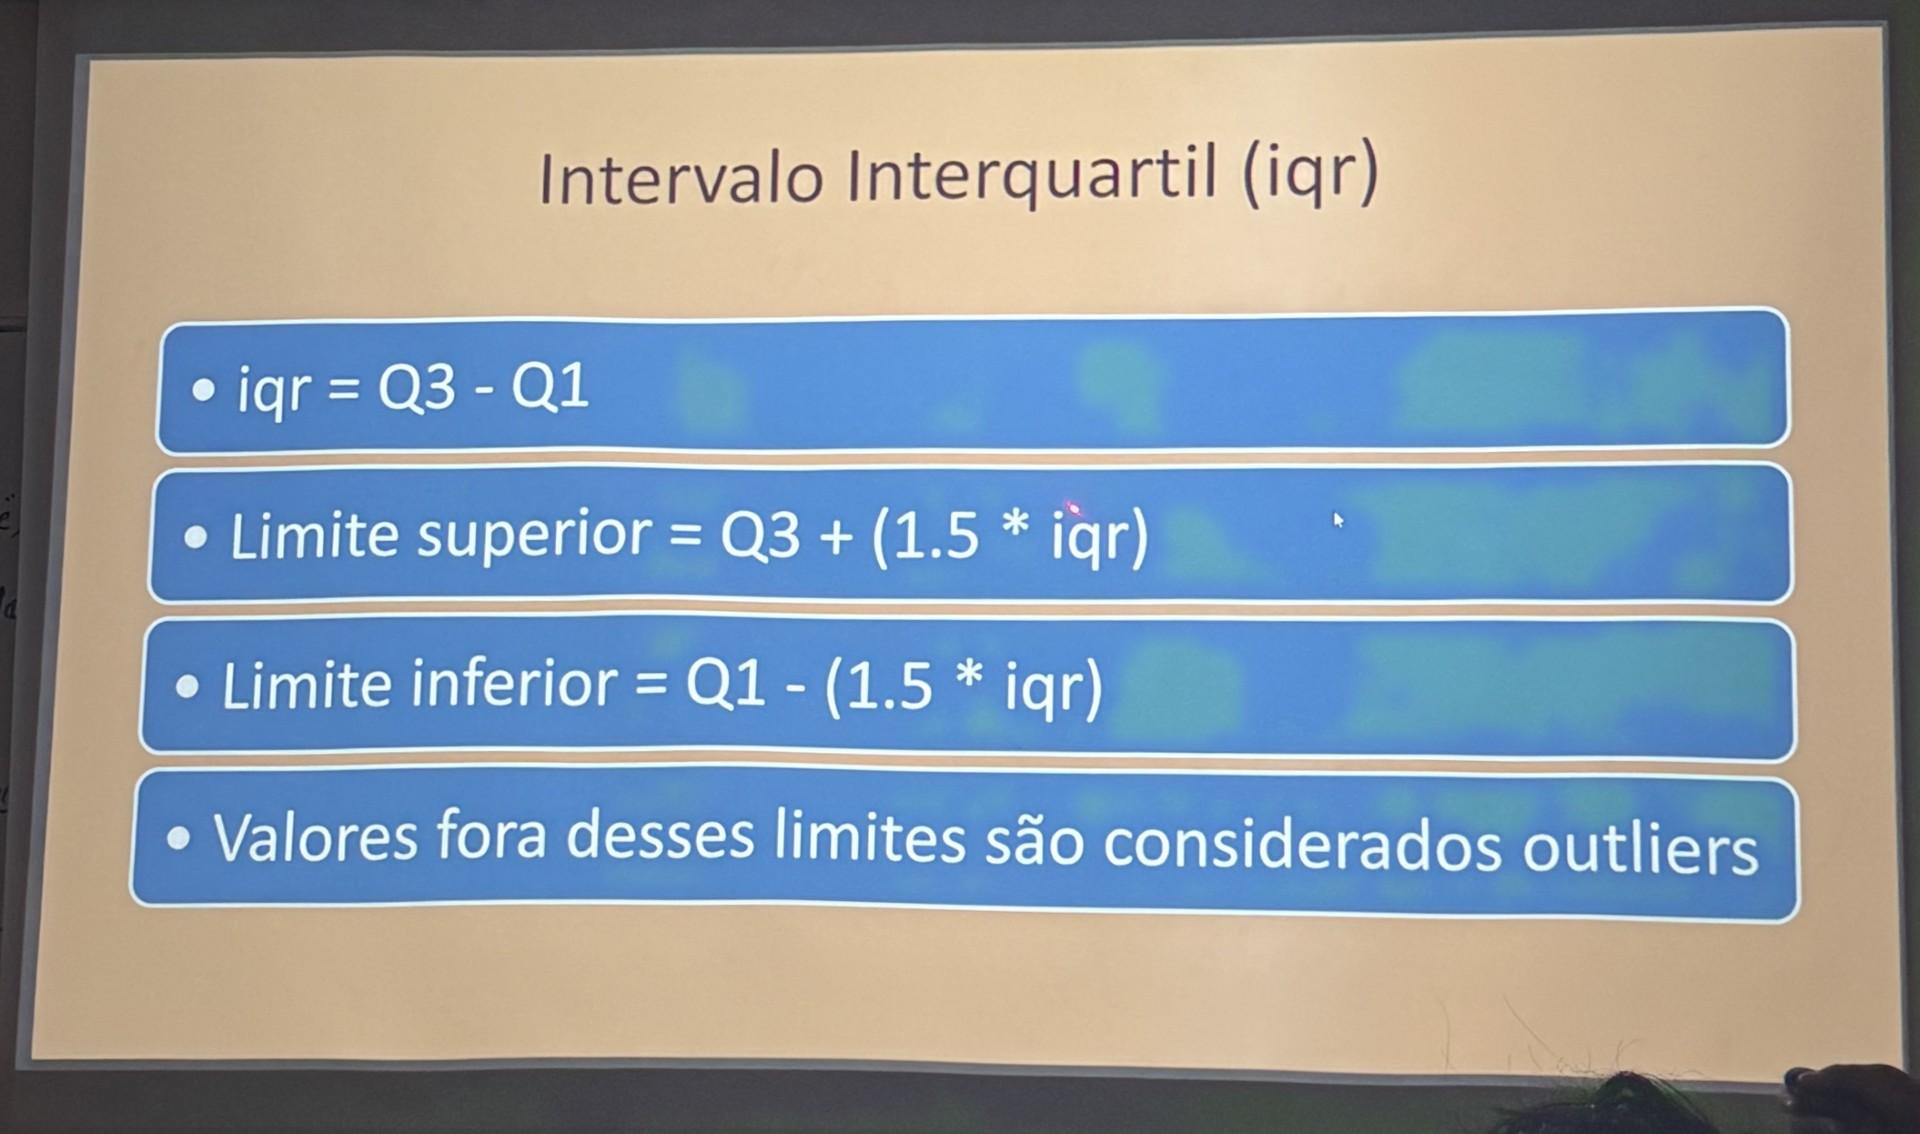

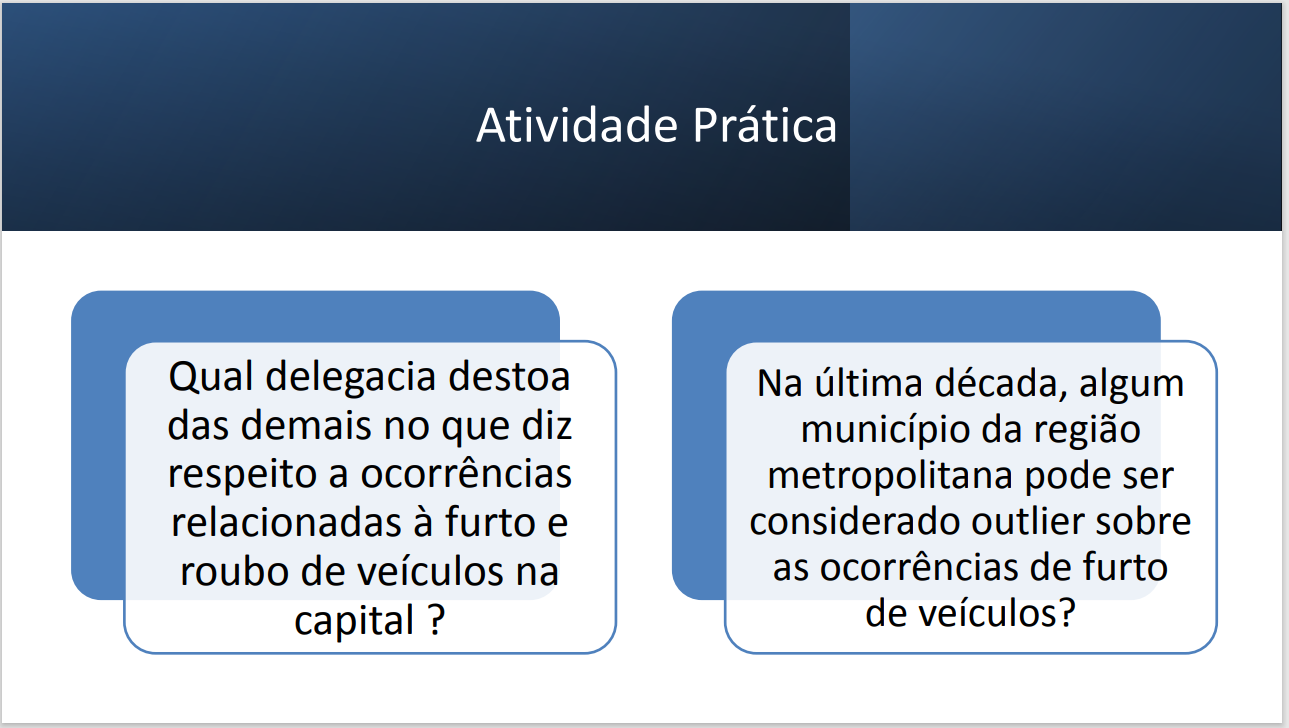